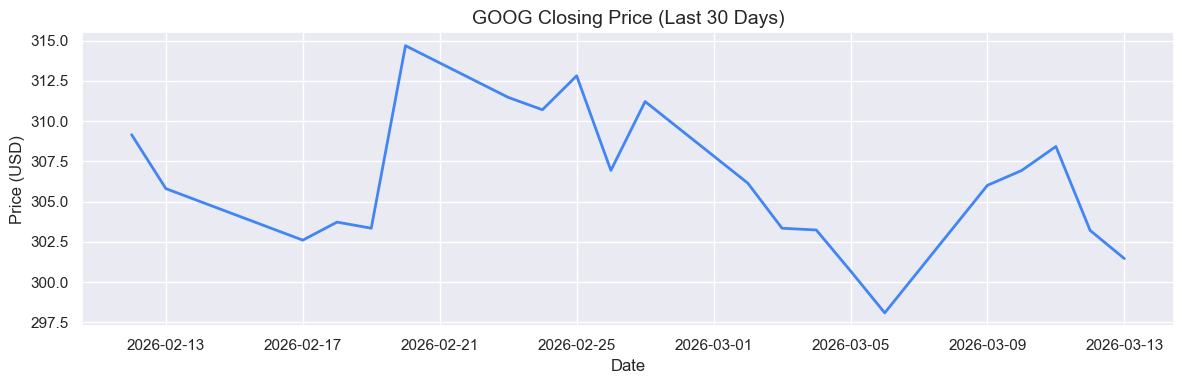

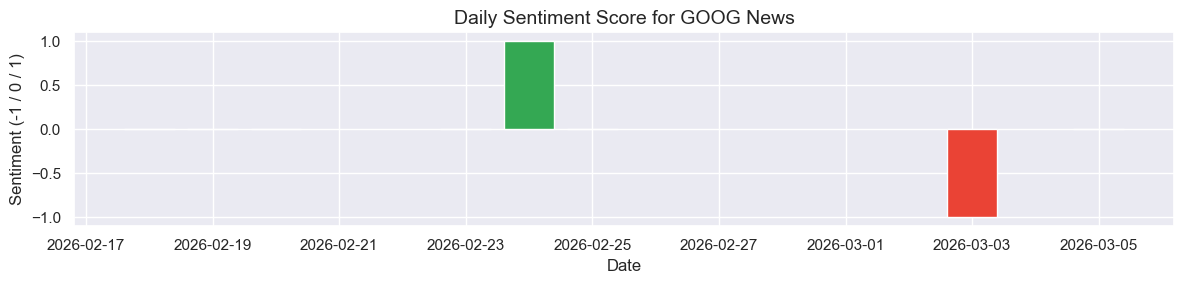

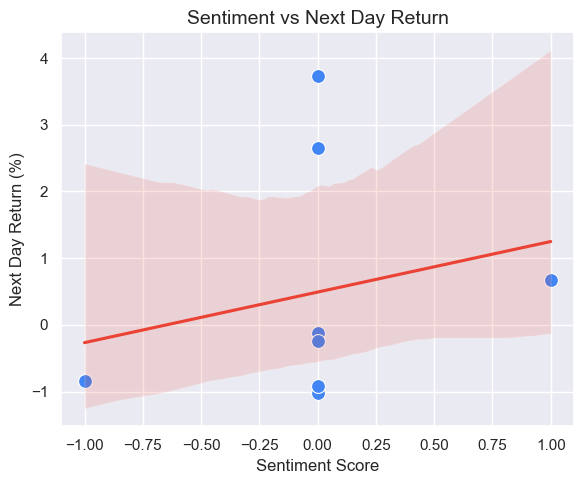

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("data/GOOG_final_dataset.csv")
df_prices = pd.read_csv("data/GOOG_prices.csv", index_col=0)

df["date"] = pd.to_datetime(df["date"])
df_prices.index = pd.to_datetime(df_prices.index)

sns.set_theme(style="darkgrid")

# 2. Price over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_prices.index, df_prices["Close"], color="#4285F4", linewidth=2)
ax.set_title("GOOG Closing Price (Last 30 Days)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.savefig("data/plot_price.png", dpi=150)
plt.show()

# 3. Sentiment over time
fig, ax = plt.subplots(figsize=(12, 3))
colors = df["sentiment_score"].map({1: "#34A853", 0: "#FBBC05", -1: "#EA4335"})
ax.bar(df["date"], df["sentiment_score"], color=colors)
ax.set_title("Daily Sentiment Score for GOOG News", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Sentiment (-1 / 0 / 1)")
plt.tight_layout()
plt.savefig("data/plot_sentiment.png", dpi=150)
plt.show()

# 4. Sentiment vs next day return
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="sentiment_score", y="next_day_return", 
                s=100, color="#4285F4", ax=ax)
sns.regplot(data=df, x="sentiment_score", y="next_day_return",
            scatter=False, color="#EA4335", ax=ax)
ax.set_title("Sentiment vs Next Day Return", fontsize=14)
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Next Day Return (%)")
plt.tight_layout()
plt.savefig("data/plot_correlation.png", dpi=150)
plt.show()